In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
sys.path.append(os.path.abspath("D:/PoliPrompt-main/src")) 

In [3]:
# from poliprompt import TextClassifier,MultiModalClassifier
from poliprompt import MultiModalClassifier

2026-02-15 09:30:24,309 - faiss.loader - INFO - Loading faiss with AVX2 support.
2026-02-15 09:30:24,411 - faiss.loader - INFO - Successfully loaded faiss with AVX2 support.


警告：无法找到 langchain.chains，正在尝试应急修复...


d:\PoliPrompt-main\poliprompt_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# data_file = "../examples/topic_data.csv"
data_file = "../examples/HarmfulMemes-tiny/train-tiny.jsonl"
work_station = "../examples/TopicExperiment"
env_path = "../.env"
options = ["1", "0"]
image_dir="../examples/HarmfulMemes-tiny"
feature_col = "text"
answer_col = "label"
image_col="img"
random_state = 42
requests_per_period = 60
seconds_per_period = 60

In [5]:
import logging

# 配置日志格式
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
# 在 Notebook 环境里创建一个 logger
logger = logging.getLogger("Notebook")

In [6]:
# topic_classifier = TextClassifier(data_file, work_station, env_path, options)
topic_classifier = MultiModalClassifier(data_file, work_station, env_path, options, image_col=image_col, image_dir=image_dir)
logger.info("Running in Multi-Modal Mode.")
# if 'image_col' in locals() and image_col is not None:
#     # 实例化多模态class
#     topic_classifier = MultiModalClassifier(data_file, work_station, env_path, options, image_col=image_col, image_dir=image_dir)
#     logger.info("Running in Multi-Modal Mode.")
# else:
#     # 实例化原本的纯文本class
#     topic_classifier = TextClassifier(data_file, work_station, env_path, options)
#     logger.info("Running in Text-Only Mode.")

2026-02-15 09:30:49,320 - Notebook - INFO - Running in Multi-Modal Mode.


In [7]:
embedding_llm_name = "qwen"
reduce_method = "umap"
select_method = "kmeans"
testing = True
testing_size = 70
kshots = 5
lambda_param = 1.0

In [8]:
topic_classifier.create_few_shot_pool(embedding_llm_name, reduce_method, select_method, testing, testing_size)

2026-02-15 09:30:56,442 - poliprompt.multimodal_classifier - WARNING - You are supposed to provide 'embedding_llm_configs.json', 'reduce_configs.json', and 'select_configs.json' in the path ..\examples\TopicExperiment\infiles\configs
2026-02-15 09:33:46,384 - dashscope - ERROR - ('Connection aborted.', ConnectionResetError(10054, '远程主机强迫关闭了一个现有的连接。', None, 10054, None))


ConnectionError: ('Connection aborted.', ConnectionResetError(10054, '远程主机强迫关闭了一个现有的连接。', None, 10054, None))

In [ ]:
llm_name = "gpt-4o"
prompt_file_name = "hateful_v1.txt"

In [9]:
enhanced_description = topic_classifier.optimize_task_description(llm_name, prompt_file_name)

[{'text': 'we said we would never forget why are you voting them into our government?', 'image_path': '..\\examples\\HarmfulMemes-tiny\\img\\74386.png'}, {'text': "if there is no race it can't be homicide", 'image_path': '..\\examples\\HarmfulMemes-tiny\\img\\97180.png'}, {'text': 'everybody loves chocolate chip cookies, even hitler', 'image_path': '..\\examples\\HarmfulMemes-tiny\\img\\82403.png'}, {'text': 'we need problem solvers not racist and religious bigots in office', 'image_path': '..\\examples\\HarmfulMemes-tiny\\img\\92075.png'}, {'text': 'when you accidentally fall in the toilet', 'image_path': '..\\examples\\HarmfulMemes-tiny\\img\\25719.png'}]


100%|██████████| 5/5 [00:00<?, ?it/s]
D:\PoliPrompt-main\src\poliprompt\multimodal_classifier.py:263: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  map_chain = LLMChain(llm=model, prompt=map_prompt)
D:\PoliPrompt-main\src\poliprompt\multimodal_classifier.py:273: LangChainDeprecationWarning: This class is deprecated. Use the `create_stuff_documents_chain` constructor instead. See migration guide here: https://python.langchain.com/docs/versions/migrating_chains/stuff_docs_chain/
  combine_documents_chain = StuffDocumentsChain(llm_chain=reduce_chain, document_variable_name="docs")
D:\PoliPrompt-main\src\poliprompt\multimodal_classifier.py:276: LangChainDeprecationWarning: This class is deprecated. Please see the migration guide here for a recommended replacement: https://python.langchain.com/docs/versions/migrating_chains/map_reduce_chain/
  reduce_documents_ch

In [10]:
enhanced_description

'When classifying memes for social media content moderation, use the following concise rules:\n\n1. **Evaluate Context and Intent**: Determine if the content seeks resolution or understanding, even if it expresses strong emotions. Such content is likely not harmful.\n\n2. **Assess Humor and Imagery**: If humor or imagery does not promote hate, violence, or discrimination, classify it as neutral or harmless.\n\n3. **Check for Harmful Ideas**: Ensure the content does not explicitly promote harmful or discriminatory ideas. If absent, classify it as not hateful/harmful.\n\n4. **Consider Profanity and Strong Language**: Profanity does not automatically make content harmful. If used humorously or playfully without promoting hate, classify it as not hateful/harmful.\n\n5. **Focus on Positive Messages**: If the content promotes positive or charitable messages without elements of hate, violence, or discrimination, classify it as not hateful/harmful.\n\nThese rules help determine whether a meme 

In [ ]:
llm1_name = "gpt-4o"
enhanced_prompt_file_name = "enhanced_hateful_v1.txt"

In [ ]:
testing_size = 64

2026-02-15 05:30:15,920 - poliprompt.multimodal_classifier - INFO - Starting new annotation file: ..\examples\TopicExperiment\outfiles\train-tiny_gpt-4o_enhanced_hateful_v1_5shots_test.csv


--- Starting Agentic Annotation (Pending: 64 rows) ---

--- [Row 4] Manual Intervention Required ---
Text: i love everything and everybody! except for squirrels i hate squirrels
AI Suggestion: 0 (Confidence: 0.95)


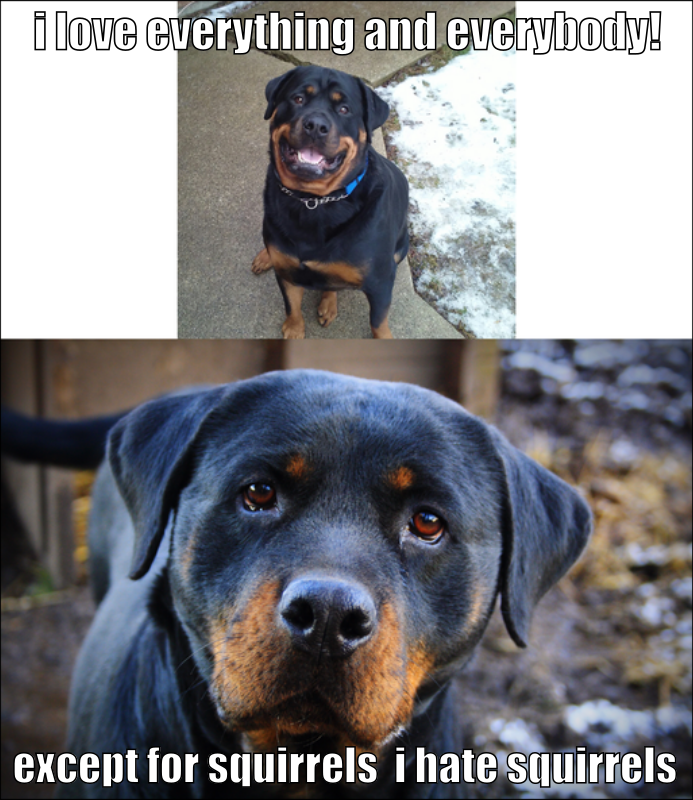

DEBUG: query_embedding 形状: (1, 2)
DEBUG: pool_embeddings 形状: (4, 2)
--- AI Analyzing Row 5 ---


2026-02-15 05:30:25,902 - poliprompt.multimodal_classifier - INFO - Process Time: 00:00:09


>>> Row 5 Confidence: 0.9500

[PAUSED] Row 5 needs manual intervention. Run annotate() again after providing input.


In [14]:
# test example
topic_classifier.annotate(llm1_name, enhanced_prompt_file_name, kshots, lambda_param, False, testing, testing_size)

In [11]:
# original code
topic_classifier.annotate(llm1_name, enhanced_prompt_file_name, kshots, lambda_param, False, testing, testing_size)

2026-02-15 05:10:22,546 - poliprompt.multimodal_classifier - INFO - Starting new annotation file: ..\examples\TopicExperiment\outfiles\train-tiny_gpt-4o_enhanced_hateful_v1_5shots_test.csv


--- Starting Agentic Annotation (Pending: 16 rows) ---
DEBUG: query_embedding 形状: (1, 2)
DEBUG: pool_embeddings 形状: (2, 2)
--- AI Analyzing Row 0 ---
>>> Row 0 Confidence: 0.9500
--- [Row 0] AI Confidence high. Auto-labeling: 0 ---
DEBUG: query_embedding 形状: (1, 2)
DEBUG: pool_embeddings 形状: (2, 2)
--- AI Analyzing Row 1 ---
>>> Row 1 Confidence: 0.9500
--- [Row 1] AI Confidence high. Auto-labeling: 0 ---
DEBUG: query_embedding 形状: (1, 2)
DEBUG: pool_embeddings 形状: (2, 2)
--- AI Analyzing Row 2 ---
>>> Row 2 Confidence: 0.9500
--- [Row 2] AI Confidence high. Auto-labeling: 0 ---
DEBUG: query_embedding 形状: (1, 2)
DEBUG: pool_embeddings 形状: (2, 2)
--- AI Analyzing Row 3 ---
>>> Row 3 Confidence: 0.9500
--- [Row 3] AI Confidence high. Auto-labeling: 0 ---
DEBUG: query_embedding 形状: (1, 2)
DEBUG: pool_embeddings 形状: (2, 2)
--- AI Analyzing Row 4 ---
>>> Row 4 Confidence: 0.9500
--- [Row 4] AI Confidence high. Auto-labeling: 0 ---
>>> Row 5 Confidence: 1.0000
--- [Row 5] AI Confidence high.

2026-02-15 05:11:20,200 - poliprompt.multimodal_classifier - INFO - Process Time: 00:00:55
2026-02-15 05:11:20,214 - poliprompt.multimodal_classifier - INFO - Progress synced to: ..\examples\TopicExperiment\outfiles\train-tiny_gpt-4o_enhanced_hateful_v1_5shots_test.csv


>>> Row 15 Confidence: 0.9500
--- [Row 15] AI Confidence high. Auto-labeling: 0 ---


In [19]:
cot_llm_name = "gpt-4o"
mismatch_file_name = "mismatch.json"
cot_prompt_file_name = "cot_prompt_harmful_v1.txt"

In [20]:
topic_classifier.cot_mismatch_solver(cot_llm_name, mismatch_file_name, cot_prompt_file_name, kshots, lambda_param, False, testing, testing_size)

2026-01-25 03:32:52,782 - poliprompt.text_classifier - INFO - Computation time: 00:00:05
2026-01-25 03:32:52,785 - poliprompt.text_classifier - INFO - Results saved to ..\examples\TopicExperiment\outfiles\cot_mismatch_train-tiny_gpt-4o_cot_prompt_harmful_v1_5shots_test.csv


In [14]:
judge_llm_name = "gpt-4-turbo"
llm2_name = "claude-3-haiku-20240307"
cot_prompt_file_name = "cot_prompt.txt"
judge_prompt_file_name = "judge_prompt.txt"

In [15]:
topic_classifier.judge_mismatch_solver(judge_llm_name, llm1_name, llm2_name, mismatch_file_name, cot_prompt_file_name, judge_prompt_file_name, kshots, lambda_param, False, testing, testing_size)

2024-10-16 11:35:54,874 - poliprompt.text_classifier - INFO - Computation time: 00:00:52
2024-10-16 11:35:54,887 - poliprompt.text_classifier - INFO - Results saved to ../examples/TopicExperiment/outfiles/judge_mismatch_topic_data_gpt-4-turbo_judge_prompt_5shots_test.csv
